In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from numpy.typing import NDArray
import tempfile
import gzip
import pylhe
from typing import Tuple, Union



pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

colors = sns.color_palette('Paired')

# Functions to read the LHE and extract the kinematic variables

In [2]:
def getLHEevents(fpath : str) -> Tuple[int,list,str]:
    """
    Reads a set of LHE files and returns a dictionary with the file labels as keys
    and the PyLHE Events object as values.
    """
    # Create temp file to handle syntax errors in LHE
    fd, fixedFile = tempfile.mkstemp(suffix='.lhe')
    os.close(fd)
    
    try:
        with gzip.open(fpath, 'rt') as f:
            # Optimize: Read and filter lines efficiently
            # Using list comprehension is slightly faster than appending in loop
            lines = [l for l in f if 'generate' not in l]
            
        with open(fixedFile, 'w') as newF:
            newF.writelines(lines)
            
        # Pylhe reads the file
        events = list(pylhe.read_lhe_with_attributes(fixedFile))
        nevents = pylhe.read_num_events(fixedFile)
        initBlock = pylhe.read_lhe_init(fixedFile)
        initBlock = initBlock['procInfo'][0]
    finally:
        if os.path.exists(fixedFile):
            os.remove(fixedFile)
            
    return nevents, events, initBlock

def getMTT(filename : str) -> Tuple[NDArray,NDArray]:
    """
    Function that reads the LHE file and extracts the distributions
    """
    
    _, events, _ = getLHEevents(filename)
    mtt = [] # invariant mass for each event
    weight = [] # weight for each event
    
    for i,ev in enumerate(events):
        weight.append(float(ev.eventinfo.weight))
        p_t = None
        p_tbar = None        
        for ptc in ev.particles:
            if ptc.id == 6:
                p_t = np.array([ptc.px, ptc.py, ptc.pz, ptc.e])
            elif ptc.id == -6:
                p_tbar = np.array([ptc.px, ptc.py, ptc.pz, ptc.e])

        #Ensure we found both
        if p_t is None or p_tbar is None:
            raise ValueError(f"Could not find t and tbar in the event {i}")
    
        # Invariant Mass (mTT)
        # m = sqrt(E^2 - p^2)
        p_tot = p_t + p_tbar
        mtt.append(np.sqrt(p_tot[3]**2 - np.dot(p_tot[:3],p_tot[:3])))
    
    
    mtt = np.array(mtt)
    weight = np.array(weight)
    return mtt,weight

## Function to extract the total cross-section from MG5 output

In [3]:
# Get cross-section data (for LO events)
def getXsecFromBanner(bannerPath : str) -> Union[float,None]:

    with open(bannerPath,'r') as bannerF:
        bannerData = bannerF.read()

    xsec = None
    if '<MGGenerationInfo>' in bannerData:
        eventData = bannerData.split('<MGGenerationInfo>')[1].split('</MGGenerationInfo>')[0]
        xsec = eval(eventData.split('\n')[2].split(':')[1].strip())

    return xsec

# Get cross-section data (for NLO events)
def getXsecFromSummary(summaryPath : str) -> Union[float,None]:

    xsec  = None
    with open(summaryPath,'r') as f:
        summaryLines = f.readlines()
    totalXsecLine = [l for l in summaryLines if 'Total cross section' in l][0]
    if 'DO NOT USE' in totalXsecLine:
        totalXsecLine = [i for i,l in enumerate(summaryLines) if 'Scale variation' in l][0]
        totalXsecLine = summaryLines[totalXsecLine+2]
    if 'Total cross section' in totalXsecLine:
        totalXsecLine = totalXsecLine.split(':')[1].strip()
    totalXsecLine = totalXsecLine.split(' +')[0].strip()
    totalXsecLine = totalXsecLine.replace('pb','')
    xsec = float(totalXsecLine)

    return xsec

# Read events and rescale weights

In [4]:
sm_mtt,sm_weight = getMTT('./data_samples/SM/SM_events.lhe.gz')
sm_xsec = sum(sm_weight)/len(sm_weight)
print(f"SM cross-section (pb) = {sm_xsec:1.3f}")
print(f"The weights will be rescaled by {sm_xsec/sum(sm_weight):1.3e}")
sm_weight = (sm_xsec/sum(sm_weight))*sm_weight

SM cross-section (pb) = 465.845
The weights will be rescaled by 2.000e-06


In [5]:
scalar_mtt,scalar_weight = getMTT('./data_samples/Scalar/Scalar_m1_1000_m0_900_y_10_events.lhe.gz')
scalar_xsec = getXsecFromSummary('./data_samples/Scalar/Scalar_m1_1000_m0_900_y_10_summary.txt')
print(f"SM+Scalar cross-section (pb) = {scalar_xsec:1.3f}")
print(f"The weights will be rescaled by {scalar_xsec/sum(scalar_weight):1.3e}")
scalar_weight = (scalar_xsec/sum(scalar_weight))*scalar_weight

SM+Scalar cross-section (pb) = 466.100
The weights will be rescaled by 5.487e+01


In [6]:
vlf_mtt,vlf_weight = getMTT('./data_samples/VLF/VLF_m1_1000_m0_900_y_6_events.lhe.gz')
vlf_xsec = getXsecFromSummary('./data_samples/VLF/VLF_m1_1000_m0_900_y_6_summary.txt')
print(f"SM+VLF cross-section (pb) = {vlf_xsec:1.3f}")
print(f"The weights will be rescaled by {vlf_xsec/sum(vlf_weight):1.3e}")
vlf_weight = (vlf_xsec/sum(vlf_weight))*vlf_weight

SM+VLF cross-section (pb) = 472.300
The weights will be rescaled by 5.773e+01


In [7]:
zp_mtt,zp_weight = getMTT('./data_samples/Zprime/Zp_m1_2000_events.lhe.gz')
zp_xsec = sum(zp_weight)/len(zp_weight)
print(f"SM+Zp cross-section (pb) = {zp_xsec:1.3f}")
print(f"The weights will be rescaled by {zp_xsec/sum(zp_weight):1.3e}")
zp_weight = (zp_xsec/sum(zp_weight))*zp_weight

SM+Zp cross-section (pb) = 476.782
The weights will be rescaled by 2.000e-06


# Plotting the invariant mass

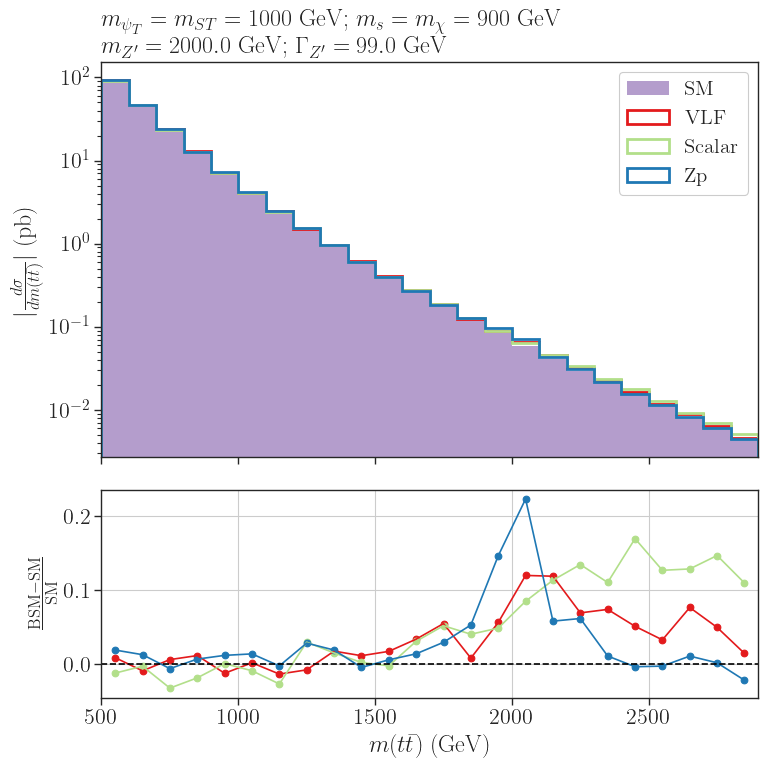

In [8]:
# Setup and Binning
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

bins = np.arange(500., 3000., 100.)
x = (bins[:-1] + bins[1:]) / 2.0  # Bin centers

colorDict = {'Scalar' : colors[2], 'VLF' : colors[5], 'Zp': colors[1], 'SM' : colors[9]}
distDict = {'VLF' : vlf_mtt, 'Scalar': scalar_mtt, 'Zp' : zp_mtt}
weightDict = {'Scalar' : scalar_weight, 'VLF' : vlf_weight, 'Zp' : zp_weight}

# Plot SM histogram
color = colorDict['SM']
# Compute histograms and its mc error
sm_hist, _ = np.histogram(sm_mtt, bins=bins, weights=sm_weight)
    
# Define Visual Styles 
alpha  = 0.5
lw     = 0
fill   = True
    
# Plot Top Subplot
axarr[0].hist(bins[:-1], weights=np.abs(sm_hist), label='SM', bins=bins, 
                color=color, alpha=alpha, histtype='step', 
                linewidth=lw, fill=fill, zorder=0)


# Plot BSM histograms
bsm_hists = {}
for label,dist in distDict.items():
    color = colorDict[label]
    weight = weightDict[label]
    
    # Compute histograms and its mc error
    h, _ = np.histogram(dist, bins=bins, weights=weight)
    
    # Define Visual Styles 
    alpha  = 1.0
    lw     = 2
    fill   = False
    
    # Plot Top Subplot
    axarr[0].hist(bins[:-1], weights=np.abs(h), label=label, bins=bins, 
                  color=color, alpha=alpha, histtype='step', 
                  linewidth=lw, fill=fill)
    bsm_hists[label] = h

############
#  SUBPLOT #
# ############
for label,bsm_hist in bsm_hists.items():
    diff = bsm_hist - sm_hist
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.nan_to_num(diff / sm_hist) 

    axarr[1].scatter(x, ratio, color=colorDict[label], label=label)
    axarr[1].plot(x, ratio, color=colorDict[label])


#################
#  Plot configs #
#################
# Top Plot
axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
axarr[0].set_yscale('log')
axarr[0].set_ylabel(r'$|\frac{d \sigma}{d m(t\bar{t})}|$ (pb)')
axarr[0].set_xlim(bins.min(), bins.max())

mPsiT = 1000.0
mSDM  = 900.0
yDM   = 6.0
mZp = 2000.0
wZp = 99.0
axarr[0].set_title(
    (r'$m_{\psi_T} = m_{ST} = %1.0f$ GeV; $m_{s} = m_\chi = %1.0f$ GeV' + '\n' +
     r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') % 
    (mPsiT, mSDM, mZp, wZp), loc='left'
)

# Subplot
axarr[1].axhline(y=0, color='k', linestyle='--') 
axarr[1].set_ylabel(r'$\frac{{\rm BSM - SM}}{{\rm SM}}$') 
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
axarr[1].grid(True)
# axarr[1].set_yticks(np.arange(-3.0, 16.0, 2.0))

plt.tight_layout()
plt.show()